# Chronos-2 Benchmark v1 - Vietnam Baseline

Goal: use Chronos-2 as a clean zero-shot benchmark on Vietnam data for direct comparison with TFT and future models.

This notebook keeps the same time split and metrics style, but does not fine-tune or calibrate Chronos-2.

In [5]:
# CELL 1 - IMPORTS & PATHS
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import torch

warnings.filterwarnings('ignore')

BASE_DIR = Path('.')
VN_DATA_PATH = BASE_DIR / 'data' / 'processed' / 'VN_data' / 'vn_tft_ready.csv'
SOURCE_METRICS_PATH = BASE_DIR / 'checkpoint' / 'chronos2_v1' / 'chronos2_v1_metrics.json'
OUT_DIR = BASE_DIR / 'checkpoint' / 'chronos2_vn_v1'
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('VN data:', VN_DATA_PATH)
print('Source metrics exists:', SOURCE_METRICS_PATH.exists())
print('Output dir:', OUT_DIR)

VN data: data\processed\VN_data\vn_tft_ready.csv
Source metrics exists: True
Output dir: checkpoint\chronos2_vn_v1


In [6]:
# CELL 2 - INSTALL / CHECK DEPENDENCIES
# Chronos-2 yêu cầu chronos-forecasting>=2.0
import sys, subprocess
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-U',
                        'chronos-forecasting>=2.0', 'scikit-learn', '-q'])

import importlib.metadata
try:
    ver = importlib.metadata.version('chronos-forecasting')
    print(f'chronos-forecasting version: {ver}')
except Exception:
    print('Không lấy được version')

chronos-forecasting version: 2.2.2


In [7]:
# CELL 3 - CONFIG
CFG = {
    # Chronos-2 is used as a benchmark-only zero-shot baseline here.
    'model_id': 'amazon/chronos-2',
    'device': 'cuda' if torch.cuda.is_available() else 'cpu',
    'torch_dtype': 'bfloat16' if torch.cuda.is_available() else 'float32',
    'context_length': 24,
    'prediction_length': 6,
    'test_months': 12,        # Final holdout
    'num_samples': 100,
    'quantiles': [0.1, 0.25, 0.5, 0.75, 0.9],
    'seed': 42,
    'hf_cache_dir': str((Path('.') / 'checkpoint' / 'hf_cache').resolve()),
}

np.random.seed(CFG['seed'])
torch.manual_seed(CFG['seed'])

for k, v in CFG.items():
    print(f'{k:<20}: {v}')

model_id            : amazon/chronos-2
device              : cuda
torch_dtype         : bfloat16
context_length      : 24
prediction_length   : 6
test_months         : 12
num_samples         : 100
quantiles           : [0.1, 0.25, 0.5, 0.75, 0.9]
seed                : 42
hf_cache_dir        : C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint\hf_cache


In [8]:
# CELL 4 - LOAD CHRONOS-2 PIPELINE
# Chronos-2 dùng Chronos2Pipeline, KHÔNG dùng ChronosPipeline cũ.
import os
import importlib.util
from pathlib import Path

if importlib.util.find_spec('chronos') is None:
    raise ModuleNotFoundError(
        "Module 'chronos' is not installed. Run Cell 2 first, then restart kernel."
    )

from chronos import Chronos2Pipeline

cache_dir = Path(CFG.get('hf_cache_dir', './checkpoint/hf_cache'))
cache_dir.mkdir(parents=True, exist_ok=True)
os.environ['HF_HOME'] = str(cache_dir)
os.environ['HUGGINGFACE_HUB_CACHE'] = str(cache_dir)
os.environ['TRANSFORMERS_CACHE'] = str(cache_dir)

dtype_map = {
    'float32': None,        # Chronos2Pipeline mặc định float32
    'bfloat16': 'bfloat16',
    'float16': 'float16',
}

print(f'Loading Chronos-2: {CFG["model_id"]}')
print(f'Device: {CFG["device"]}  |  dtype: {CFG["torch_dtype"]}')

pipeline = Chronos2Pipeline.from_pretrained(
    CFG['model_id'],
    device_map=CFG['device'],
)

CFG['loaded_model_id'] = CFG['model_id']
print('Chronos-2 pipeline loaded:', CFG['model_id'])
print('HF cache dir:', cache_dir)

Loading Chronos-2: amazon/chronos-2
Device: cuda  |  dtype: bfloat16
Chronos-2 pipeline loaded: amazon/chronos-2
HF cache dir: C:\Users\ADMIN\OneDrive - Hanoi University of Mining and Geology\Documents\NCKH\TFT-GreenPower-Forecasting\checkpoint\hf_cache


In [9]:
# CELL 5 - LOAD & PREP VN DATA
FINE_TUNE_SERIES = ['Coal', 'Gas', 'Hydro', 'Solar', 'Wind']

df = pd.read_csv(VN_DATA_PATH)
df['date'] = pd.to_datetime(df['date'])
df = df[df['series'].isin(FINE_TUNE_SERIES)].copy()

df = df.sort_values(['entity', 'series', 'date'])
df['group_id'] = df['entity'].astype(str) + '||' + df['series'].astype(str)
df['time_idx'] = df.groupby('group_id')['date'].rank(method='dense').astype(int) - 1

print('Shape:', df.shape)
print('Groups:', df['group_id'].nunique())
print('Date range:', df['date'].min().date(), '->', df['date'].max().date())

Shape: (360, 31)
Groups: 5
Date range: 2019-01-01 -> 2024-12-01


In [10]:
# CELL 6 - SPLIT (train / test benchmark)
max_time = int(df['time_idx'].max())
test_start = max_time - CFG['test_months'] + 1

train_df = df[df['time_idx'] < test_start].copy()
test_df = df[df['time_idx'] >= test_start].copy()

print('train rows :', len(train_df))
print('test rows  :', len(test_df))
print('train range:', train_df['date'].min().date(), '->', train_df['date'].max().date())
print('test range :', test_df['date'].min().date(), '->', test_df['date'].max().date())

train rows : 300
test rows  : 60
train range: 2019-01-01 -> 2023-12-01
test range : 2024-01-01 -> 2024-12-01


In [11]:
# CELL 7 - HELPERS (Chronos2Pipeline dùng predict_df)

def smape(y_true, y_pred):
    denom = np.abs(y_true) + np.abs(y_pred) + 1e-8
    return np.mean(2.0 * np.abs(y_true - y_pred) / denom) * 100.0

def wape(y_true, y_pred):
    return np.sum(np.abs(y_true - y_pred)) / (np.sum(np.abs(y_true)) + 1e-8) * 100.0

from sklearn.metrics import r2_score

def eval_metrics(y_true, y_pred):
    return {
        'mae': float(np.mean(np.abs(y_true - y_pred))),
        'rmse': float(np.sqrt(np.mean((y_true - y_pred) ** 2))),
        'smape': float(smape(y_true, y_pred)),
        'wape': float(wape(y_true, y_pred)),
        'r2': float(r2_score(y_true, y_pred)),
    }


def run_group_forecast_zeroshot(pipeline, g, test_start, prediction_length,
                                context_length):
    """
    Zero-shot forecast cho 1 group dùng Chronos2Pipeline.predict_df.
    Trả về list dict rows (y_pred_raw).
    """
    max_idx = int(g['time_idx'].max())
    rows = []

    for t in range(test_start, max_idx + 1, prediction_length):
        hist = g[g['time_idx'] < t].tail(context_length)
        if len(hist) < context_length:
            continue

        ctx = pd.DataFrame({
            'id': '0',
            'timestamp': hist['date'].values,
            'target': hist['generation_TWh'].values,
        })

        pred_df_out = pipeline.predict_df(
            ctx,
            prediction_length=prediction_length,
            quantile_levels=[0.1, 0.5, 0.9],
            id_column='id',
            timestamp_column='timestamp',
            target='target',
        )
        pred_df_out = pred_df_out.sort_values('timestamp').reset_index(drop=True)

        future_idx = list(range(t, min(t + prediction_length, max_idx + 1)))
        g_future = g[g['time_idx'].isin(future_idx)].sort_values('time_idx')

        for j, (_, r) in enumerate(g_future.iterrows()):
            if j >= len(pred_df_out):
                break
            p_row = pred_df_out.iloc[j]
            rows.append({
                'group_id': g['group_id'].iloc[0],
                'entity': r['entity'],
                'series': r['series'],
                'date': r['date'],
                'time_idx': int(r['time_idx']),
                'y_true': float(r['generation_TWh']),
                'y_pred_raw': float(p_row.get('predictions', p_row.get('0.5', np.nan))),
            })
    return rows

In [12]:
# CELL 8 - PHASE 1 (ZERO-SHOT PREDICTION ON TEST)
rows = []

groups = list(df.groupby('group_id'))
print(f'Zero-shot forecasting {len(groups)} groups...')

for i, (gid, g) in enumerate(groups):
    g = g.sort_values('time_idx').reset_index(drop=True)
    gr = run_group_forecast_zeroshot(
        pipeline=pipeline,
        g=g,
        test_start=test_start,
        prediction_length=CFG['prediction_length'],
        context_length=CFG['context_length'],
    )
    rows.extend(gr)
    if (i + 1) % 5 == 0:
        print(f'  {i+1}/{len(groups)} groups done...')

pred_all = pd.DataFrame(rows).sort_values(['group_id', 'time_idx']).reset_index(drop=True)
pred_test = pred_all.copy()

print('Pred rows test :', len(pred_test))

Zero-shot forecasting 5 groups...
  5/5 groups done...
Pred rows test : 60


In [13]:
# CELL 10 - EVALUATE RAW ZERO-SHOT BENCHMARK
if pred_test.empty:
    raise RuntimeError('No test predictions found. Check split and forecast settings.')

m_raw = eval_metrics(pred_test['y_true'].values, pred_test['y_pred_raw'].values)

print('Chronos-2 zero-shot benchmark test metrics:')
for k, v in m_raw.items():
    if k in ['mae', 'rmse', 'r2']:
        print(f'  {k.upper():<6}: {v:.4f}')
    else:
        print(f'  {k.upper():<6}: {v:.2f}%')

Chronos-2 zero-shot benchmark test metrics:
  MAE   : 1.3619
  RMSE  : 2.2124
  SMAPE : 26.54%
  WAPE  : 26.51%
  R2    : 0.7924


In [14]:
# CELL 11 - SAVE ARTIFACTS
pred_path = OUT_DIR / 'chronos2_vn_v1_test_predictions.csv'
cfg_path = OUT_DIR / 'chronos2_vn_v1_config.json'
metrics_path = OUT_DIR / 'chronos2_vn_v1_metrics.json'

pred_test.to_csv(pred_path, index=False)

metrics_bundle = {
    'benchmark_raw': m_raw,
    'n_test_predictions': int(len(pred_test)),
    'test_date_range': [str(pred_test['date'].min().date()), str(pred_test['date'].max().date())],
}

with open(cfg_path, 'w', encoding='utf-8') as f:
    json.dump(CFG, f, indent=2, ensure_ascii=False)

with open(metrics_path, 'w', encoding='utf-8') as f:
    json.dump(metrics_bundle, f, indent=2, ensure_ascii=False)

print('Saved:', pred_path)
print('Saved:', cfg_path)
print('Saved:', metrics_path)

Saved: checkpoint\chronos2_vn_v1\chronos2_vn_v1_test_predictions.csv
Saved: checkpoint\chronos2_vn_v1\chronos2_vn_v1_config.json
Saved: checkpoint\chronos2_vn_v1\chronos2_vn_v1_metrics.json


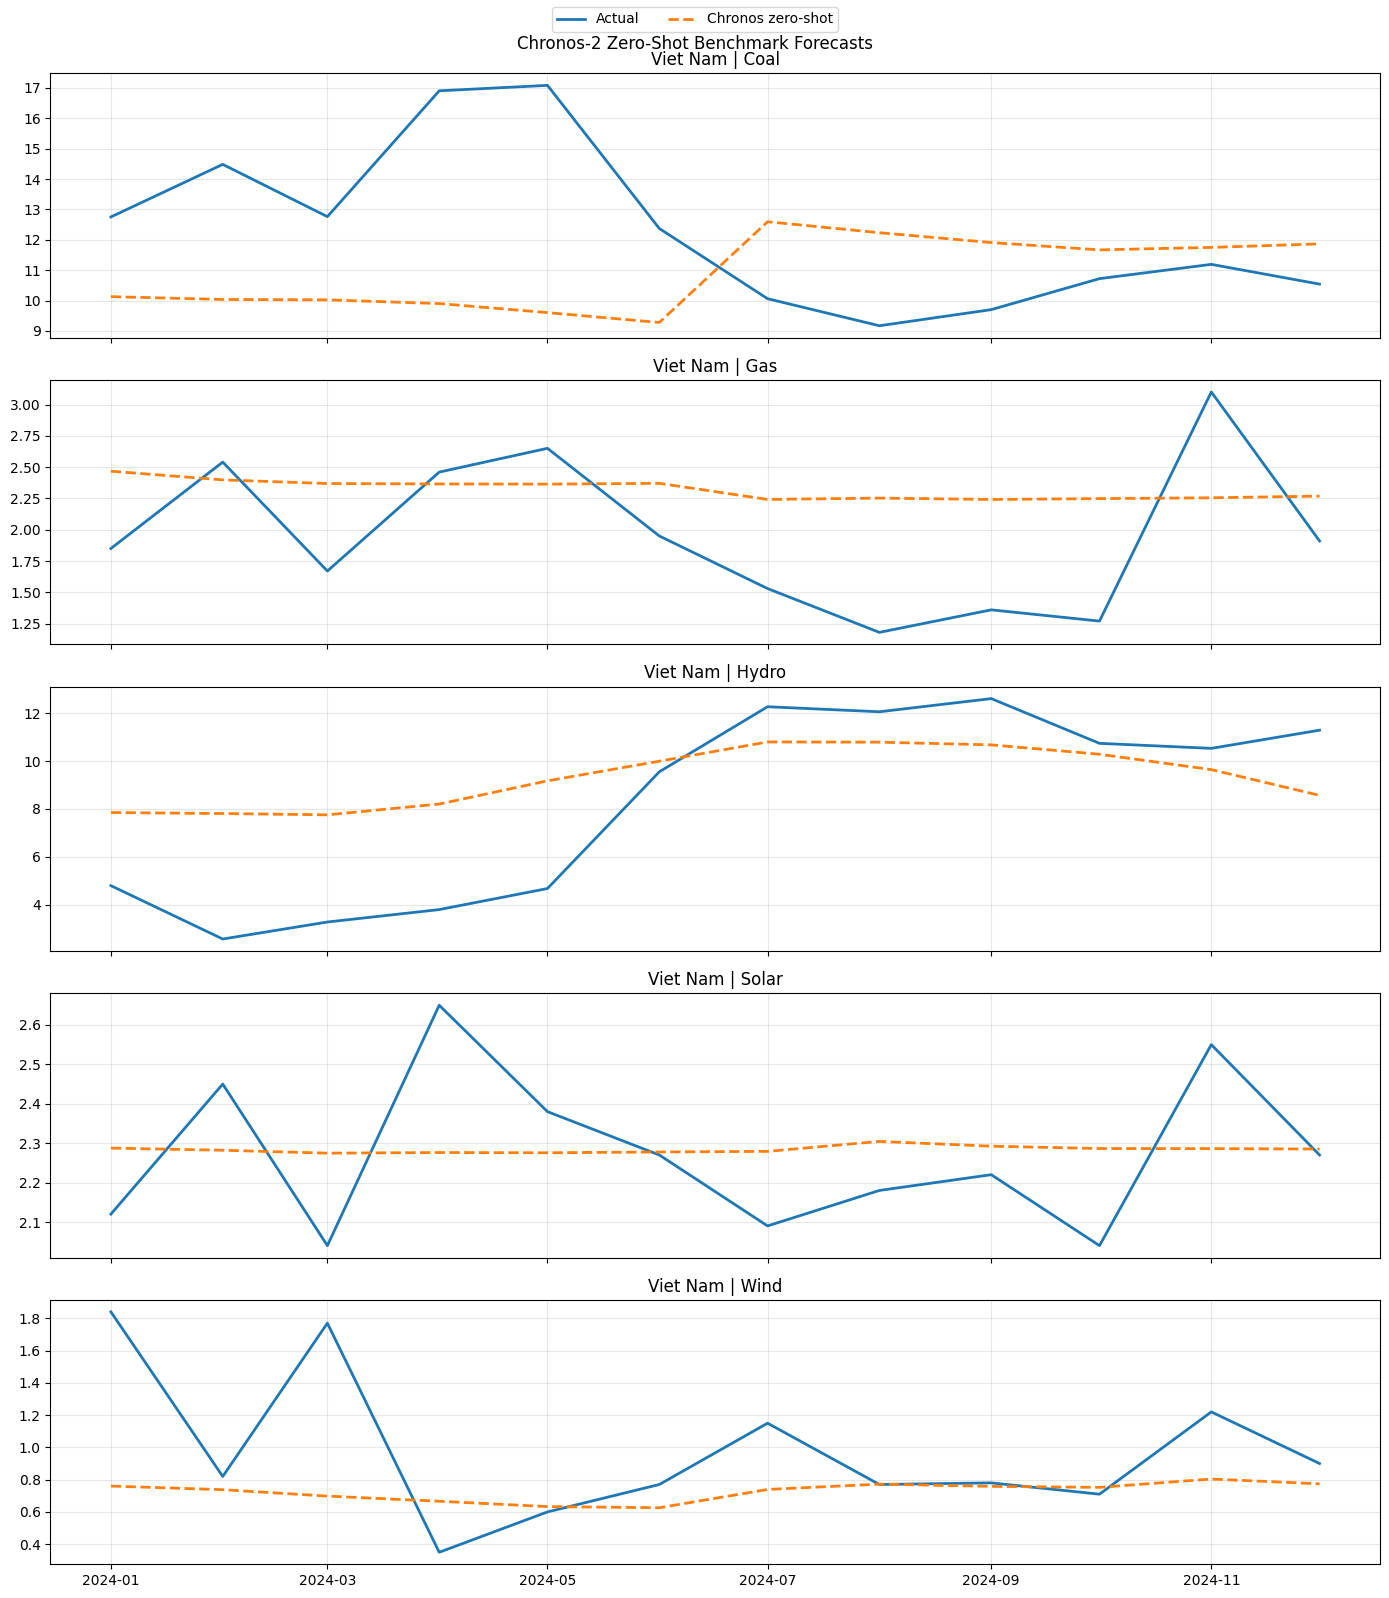

In [15]:
# CELL 12 - QUICK PLOTS
import matplotlib.pyplot as plt

plot_df = pred_test.copy()
plot_df['entity_series'] = plot_df['entity'] + ' | ' + plot_df['series']
top_groups = plot_df['entity_series'].value_counts().head(5).index.tolist()

fig, axes = plt.subplots(len(top_groups), 1, figsize=(14, 3.2 * len(top_groups)), sharex=True)
if len(top_groups) == 1:
    axes = [axes]

for ax, gname in zip(axes, top_groups):
    sub = plot_df[plot_df['entity_series'] == gname].sort_values('date')
    ax.plot(sub['date'], sub['y_true'], label='Actual', linewidth=2)
    ax.plot(sub['date'], sub['y_pred_raw'], label='Chronos zero-shot', linewidth=2, linestyle='--')
    ax.set_title(gname)
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)
fig.suptitle('Chronos-2 Zero-Shot Benchmark Forecasts')
plt.tight_layout()
plt.show()

In [16]:
# CELL 13 - FINAL SUMMARY
print('=' * 68)
print(' CHRONOS-2 ZERO-SHOT BENCHMARK SUMMARY (VN)')
print('=' * 68)
print(f" Source model            : {CFG['model_id']}")
print(f" Context / horizon        : {CFG['context_length']} / {CFG['prediction_length']}")
print(f" Test MAE                 : {m_raw['mae']:.4f}")
print(f" Test RMSE                : {m_raw['rmse']:.4f}")
print(f" Test WAPE                : {m_raw['wape']:.2f}%")
print(f" Test SMAPE               : {m_raw['smape']:.2f}%")
print(f" Test R2                  : {m_raw['r2']:.4f}")
print(f" Test predictions rows    : {len(pred_test)}")
print('=' * 68)

if SOURCE_METRICS_PATH.exists():
    with open(SOURCE_METRICS_PATH, 'r', encoding='utf-8') as f:
        src = json.load(f)
    print('Multi-country Chronos baseline (from train notebook):')
    for k in ['mae', 'rmse', 'smape', 'wape', 'r2']:
        if k in src:
            suffix = '%' if k in ['smape', 'wape'] else ''
            print(f'  {k.upper():<6}: {src[k]:.4f}{suffix}')

 CHRONOS-2 ZERO-SHOT BENCHMARK SUMMARY (VN)
 Source model            : amazon/chronos-2
 Context / horizon        : 24 / 6
 Test MAE                 : 1.3619
 Test RMSE                : 2.2124
 Test WAPE                : 26.51%
 Test SMAPE               : 26.54%
 Test R2                  : 0.7924
 Test predictions rows    : 60
Multi-country Chronos baseline (from train notebook):
  MAE   : 0.3199
  RMSE  : 0.7078
  SMAPE : 27.1408%
  WAPE  : 13.9230%
  R2    : 0.9682
